# Logistic Regression 

This project aims to determine whether a customer will churn or not using logistic regression, a popular machine learning algorithm for binary classification. 

The dataset is processed and analyzed to prepare it for modeling, and key metrics like accuracy, precision, recall, confusion matrix, ROC AUC, and precision-recall curves are computed to evaluate the model's performance.


In [ ]:
#Importing all the neccesary packages

import pandas as pd  # pandas to work on large dataset
import numpy as np  # numpy module to mathemetical computing and work with multi-dimensional array
import matplotlib.pyplot as plt  # matplotlib visualization module
import seaborn as sns # seaborn module to statistic data visualization

# Sklearn(Scikit-learn) used for machine learning and statestic modeling. Built on top of Numpy, Scipy and Matplotlib.

from sklearn.preprocessing import LabelEncoder # Importing labelencoder from sklearn preprocessing module to convert objetc data type into numerical 
from sklearn.model_selection import train_test_split  # To split the dataset into training and testing
from sklearn.linear_model import LogisticRegression  # Logistic Regression to buld model
from statsmodels.stats.outliers_influence import variance_inflation_factor # Variance inflation factor to check the multicolinerity on the features
from sklearn.metrics import * # Metrics to evaluate the model.

In [ ]:
# Reading the csv data as DataFrame using pandas

df = pd.read_csv('customer_churn_.csv')

In [ ]:
# Basic Information about the DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Top 3 values of the DataFrame

df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:
# Unique values of the each features

for col in df.columns:
    if df[col].dtype == 'object':
        print(col,'-->',df[col].unique())

customerID --> ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender --> ['Female' 'Male']
Partner --> ['Yes' 'No']
Dependents --> ['No' 'Yes']
PhoneService --> ['No' 'Yes']
MultipleLines --> ['No phone service' 'No' 'Yes']
InternetService --> ['DSL' 'Fiber optic' 'No']
OnlineSecurity --> ['No' 'Yes' 'No internet service']
OnlineBackup --> ['Yes' 'No' 'No internet service']
DeviceProtection --> ['No' 'Yes' 'No internet service']
TechSupport --> ['No' 'Yes' 'No internet service']
StreamingTV --> ['No' 'Yes' 'No internet service']
StreamingMovies --> ['No' 'Yes' 'No internet service']
Contract --> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --> ['Yes' 'No']
PaymentMethod --> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges --> ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn --> ['No' 'Yes']


In [ ]:
# Counting the unique values of TotalCharges feature, because the values inside are float but the data type in DataFrame is object.

df.TotalCharges.value_counts()

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [ ]:
# Observed 11 Empty values, so removing that

df = df[df.TotalCharges !=" "]

In [ ]:
# Converting the Totalcharges data type to float

df.TotalCharges = df.TotalCharges.astype('float')

In [ ]:
# count of duplication rows in dataset  

df.duplicated().sum()

0

In [ ]:
# Counting for null or empty values  

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

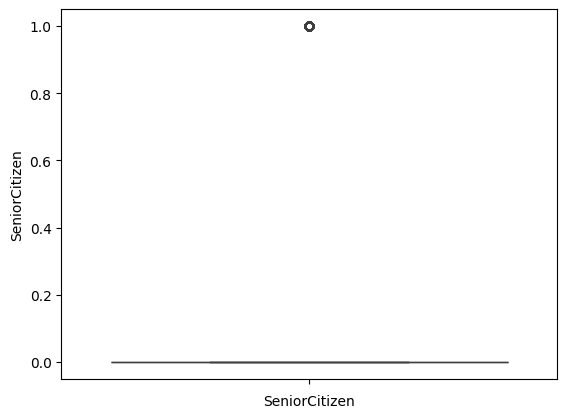

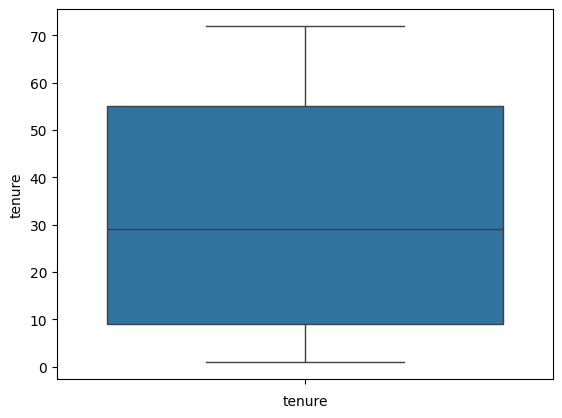

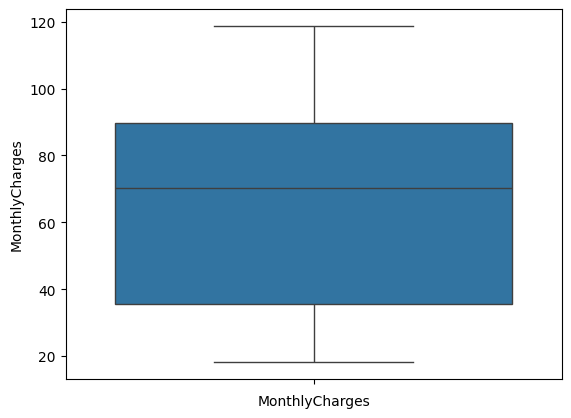

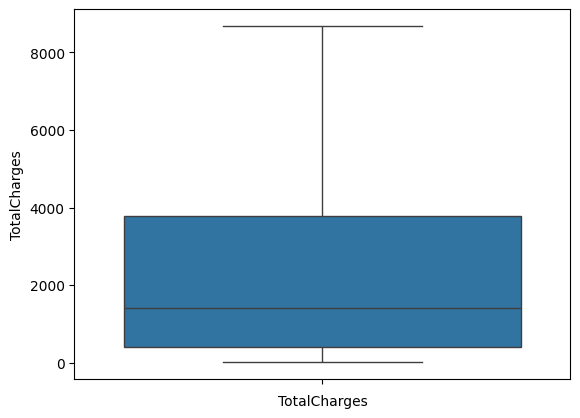

In [12]:
# Visualizing outliers for numerical columns using boxplots

for col in df.columns:
    if df[col].dtype != 'object':
        sns.boxplot(df[col])
        plt.xlabel(col)
        plt.show()

##### Observed there is no outliers in the data.

In [13]:
# Encoding categorical variables using LabelEncoder for modeling purposes

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [14]:
# Displaying dataset information after encoding

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   int32  
 1   gender            7032 non-null   int32  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int32  
 4   Dependents        7032 non-null   int32  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int32  
 7   MultipleLines     7032 non-null   int32  
 8   InternetService   7032 non-null   int32  
 9   OnlineSecurity    7032 non-null   int32  
 10  OnlineBackup      7032 non-null   int32  
 11  DeviceProtection  7032 non-null   int32  
 12  TechSupport       7032 non-null   int32  
 13  StreamingTV       7032 non-null   int32  
 14  StreamingMovies   7032 non-null   int32  
 15  Contract          7032 non-null   int32  
 16  PaperlessBilling  7032 non-null   int32  
 17  

<Axes: >

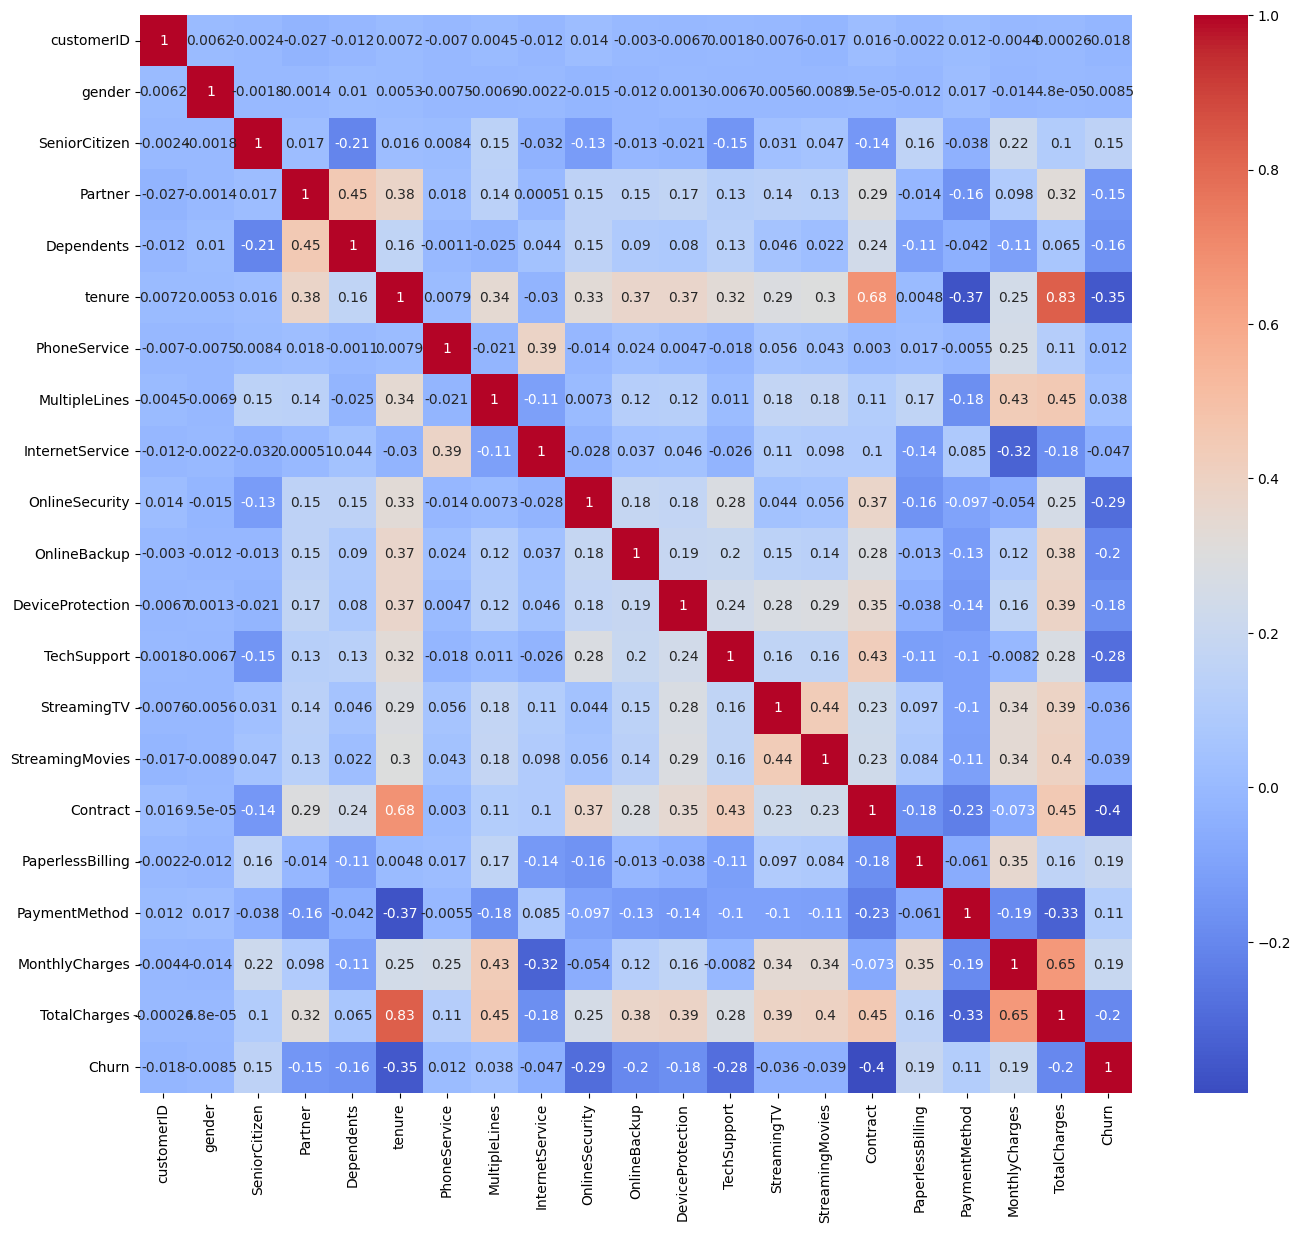

In [15]:
# Creating a heatmap to visualize correlations between variables

plt.figure(figsize=(16,14))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

In [16]:
# Splitting the dataset into features (X) and the target variable (y)


df_x = df.drop('Churn', axis=1)
df_y = df['Churn']

In [17]:
# Calculating Variance Inflation Factor (VIF) to identify multicollinearity among features

vif = pd.DataFrame()

vif_list = []
for i in range(len(df_x.columns)):
    vif_value = variance_inflation_factor(df_x.values, i)
    vif_list.append(vif_value)
vif['columns'] = df_x.columns
vif['Multi_co-linearity'] = vif_list
vif

,columns,Multi_co-linearity
0,customerID,3.702593
1,gender,1.961000
2,SeniorCitizen,1.370187
3,Partner,2.819912
4,Dependents,1.957881
5,tenure,15.570223
6,PhoneService,15.270514
7,MultipleLines,2.758529
8,InternetService,4.351030
9,OnlineSecurity,2.257669


In [18]:
# Dropping features with high multicollinearity based on VIF analysis

df_x.drop('MonthlyCharges', inplace=True, axis=1)
df_x.drop('tenure', inplace=True, axis=1)
df_x.drop('PhoneService', inplace=True, axis=1)

In [19]:
# Splitting the data into training and testing sets for model building

x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.25, random_state=100)


In [ ]:
# Creating and fitting a Logistic Regression model

lr = LogisticRegression()  #initiating the logistic regression
lr.fit(x_train, y_train)   # Train or fit with the logistic model to understand the pattern 

predict = lr.predict(x_test)

In [ ]:
# Accuracy metrics: Evaluates how much predicted values are correct from the original data. 

accuracy_score(predict, y_test)*100

76.45051194539249

<Axes: >

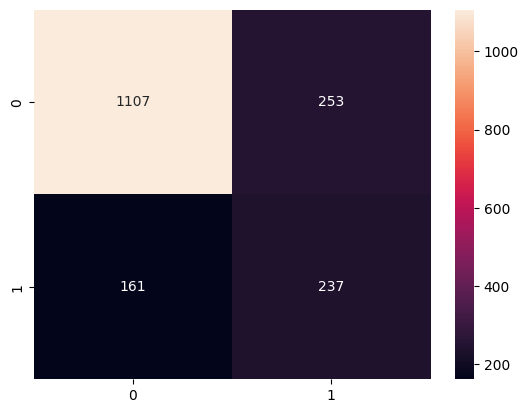

In [22]:
# Creating and visualizing a confusion matrix

cf = confusion_matrix(predict, y_test)
sns.heatmap(cf, annot=True, fmt='d')  # Annotated heatmap of confusion matrix


In [ ]:
# Precision score: Accuracy of models positive predictiveness

precision_score(y_test, predict)

0.5954773869346733

In [ ]:
# Recall is also know as sensitivity.

# Recall score: Accuracy of models on actual positive predictions

recall_score(y_test, predict)

0.48367346938775513

In [ ]:
# Calculating precision, recall, and generating a classification report

# F1 score is to evalute the model by balancing precision and recall
# Support is the number of samples belogs to each class

# Macro average treats all class as same and calculate the average.
# weighted average refers to the precision, recall, f1 score, weighted by the no of samples in each class


print(classification_report (y_test,predict))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1268
           1       0.60      0.48      0.53       490

    accuracy                           0.76      1758
   macro avg       0.70      0.68      0.69      1758
weighted avg       0.75      0.76      0.76      1758



In [ ]:
# Calculating ROC AUC score
# ROC Curve plots (Recall) against False Positive Rate

roc_auc_score(y_test,predict)

0.6783509302774737

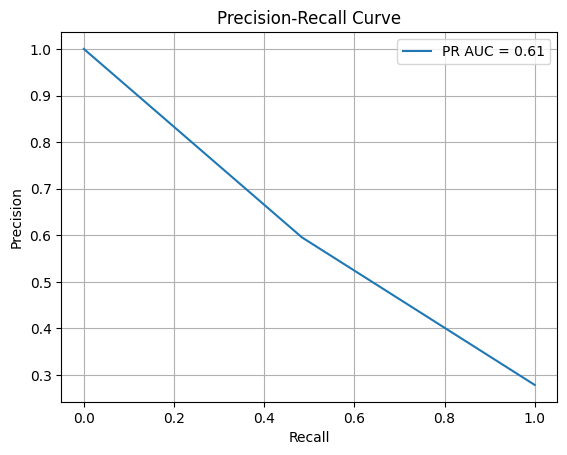

In [ ]:
# Generating and visualizing the Precision-Recall curve

# PR curve models ability to correctly calssify positive instance.


precision, recall, thresholds = precision_recall_curve(y_test, predict)

pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid()
plt.show()
